# Final EDA - Chapter 5.1–5.3

This notebook consolidates the exploratory analyses that were actually used in the final thesis text for:

- **5.1 Corpus and Metadata Coverage**
- **5.2 Authorship, Gender, and Reference Characteristics**
- **5.3 Venue and Taxonomy Composition**

It consolidates the useful material from `01_general_eda`, `01b`, `01c`, and `01d`.
Redundant exploratory checks, duplicate figure versions, unused optional plots, and drafting-only
copy-paste summary cells have been removed.

## 0. Setup and final analytical paper table

All analyses below use the final paper-level table produced after the citation filtering pipeline.
The assertions protect against accidentally running the notebook on a different analytical universe.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 100)

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "01_final_eda"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
DATA_OUTPUT_DIR = OUTPUT_DIR / "data"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
DATA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = FIGURE_DIR

df = pd.read_pickle(PROCESSED_DIR / "papers_final.pkl")

KNOWN_CATEGORIES = ["MM", "MW", "WM", "WW"]

df_cs = df[df["primary_field"].eq("Computer Science")].copy()
df_known = df[df["first_last_cat"].isin(KNOWN_CATEGORIES)].copy()
df_cs_known = df_cs[df_cs["first_last_cat"].isin(KNOWN_CATEGORIES)].copy()

print(f"Final analytical papers: {len(df):,}")
print(f"Computer Science papers: {len(df_cs):,}")
print(f"Known-gender CS papers: {len(df_cs_known):,}")
print(f"Known-gender CS coverage: {100 * len(df_cs_known) / len(df_cs):.2f}%")

Final analytical papers: 3,026,412
Computer Science papers: 1,542,691
Known-gender CS papers: 1,081,363
Known-gender CS coverage: 70.10%


# 5.1 Corpus and Metadata Coverage

Retained here are the paper-level corpus counts, metadata coverage diagnostics, publication-volume
figure, and gender-metadata coverage figure used in writing Section 5.1.

In [2]:
MISSING_STRINGS = {"", "nan", "none", "null", "n/a", "na", "unknown", "missing"}

def present_string(s):
    return (
        s.notna()
        & s.astype(str).str.strip().ne("")
        & ~s.astype(str).str.strip().str.lower().isin(MISSING_STRINGS)
    )

def normalize_gender(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "U"
    s = str(x).strip().lower()
    if s in {"m", "male", "man"}:
        return "M"
    if s in {"f", "female", "w", "woman"}:
        return "W"
    return "U"

df_eda = df
publication_year = pd.to_numeric(df_eda["year"], errors="coerce")
decade = pd.to_numeric(df_eda["decade"], errors="coerce")
cs_mask = df_eda["primary_field"].eq("Computer Science")

N = len(df_eda)
N_CS = int(cs_mask.sum())

taxonomy_available = present_string(df_eda["primary_topic_name"])
venue_name_available = present_string(df_eda["venue_name"])
venue_type_available = present_string(df_eda["venue_type"])

venue_rank_available = (
    df_eda["venue_rank_clean"].notna()
    & df_eda["venue_rank_clean"].astype(str).str.strip().ne("")
    & ~df_eda["venue_rank_clean"].astype(str).str.strip().str.upper().eq("N/A")
)

reference_list_available = df_eda["ref_lst"].map(
    lambda x: isinstance(x, (list, tuple, set, np.ndarray))
)
n_refs = pd.to_numeric(df_eda["n_refs"], errors="coerce")

first_gender = df_eda["first_author_gender"].map(normalize_gender)
last_gender = df_eda["last_author_gender"].map(normalize_gender)

first_gender_known = first_gender.isin(["M", "W"])
last_gender_known = last_gender.isin(["M", "W"])
complete_gender_known = first_gender_known & last_gender_known
gender_category = first_gender.astype(str) + last_gender.astype(str)

print(f"Computer Science share: {100 * N_CS / N:.2f}%")
print(f"First-author gender coverage: {100 * first_gender_known.mean():.2f}%")
print(f"Last-author gender coverage: {100 * last_gender_known.mean():.2f}%")
print(f"Complete first-last gender coverage: {100 * complete_gender_known.mean():.2f}%")

Computer Science share: 50.97%
First-author gender coverage: 80.26%
Last-author gender coverage: 82.14%
Complete first-last gender coverage: 69.72%


## 5.1.1 Corpus size, time span, and Computer Science scope

In [3]:
year_valid = publication_year.dropna()

overview = pd.DataFrame({
    "Statistic": [
        "Total papers",
        "Computer Science papers",
        "Computer Science share (%)",
        "Earliest publication year",
        "Latest publication year",
        "Observed publication years",
        "Observed decades",
        "Papers with recorded reference-list field",
        "Papers with >=1 recorded reference",
        "Total recorded references",
        "Papers with complete first-last gender",
        "Complete first-last gender coverage (%)"
    ],
    "Value": [
        f"{N:,}",
        f"{N_CS:,}",
        f"{100 * N_CS / N:.2f}" if N else "NA",
        int(year_valid.min()) if len(year_valid) else "NA",
        int(year_valid.max()) if len(year_valid) else "NA",
        publication_year.nunique(dropna=True),
        decade.nunique(dropna=True),
        f"{int(reference_list_available.sum()):,}",
        f"{int((n_refs > 0).sum()):,}",
        f"{int(n_refs.fillna(0).sum()):,}",
        f"{int(complete_gender_known.sum()):,}",
        f"{100 * complete_gender_known.mean():.2f}"
    ]
})

display(overview)

overview.to_csv(
    TABLE_DIR / "eda_corpus_overview.csv",
    index=False
)

,Statistic,Value
0,Total papers,"3,026,412"
1,Computer Science papers,"1,542,691"
2,Computer Science share (%),50.97
3,Earliest publication year,1950
4,Latest publication year,2024
5,Observed publication years,75
6,Observed decades,8
7,Papers with recorded reference-list field,"3,026,412"
8,Papers with >=1 recorded reference,"2,790,924"
9,Total recorded references,"22,775,752"


## 5.1.2 Metadata missingness and coverage - Table 5.2

In [4]:
coverage_variables = {
    "Publication year": publication_year.notna(),
    "Decade": decade.notna(),
    "Taxonomy label": taxonomy_available,
    "Venue name": venue_name_available,
    "Venue type": venue_type_available,
    "Venue rank": venue_rank_available,
    "Reference-list field": reference_list_available,
    "First-author gender": first_gender_known,
    "Last-author gender": last_gender_known,
    "Complete first-last gender": complete_gender_known
}

rows = []

for label, mask in coverage_variables.items():
    full_available = int(mask.sum())
    full_missing = int(N - full_available)

    if N_CS > 0:
        cs_available = int(mask[cs_mask].sum())
        cs_missing = int(N_CS - cs_available)
    else:
        cs_available = 0
        cs_missing = 0

    rows.append({
        "Variable": label,
        "Full available N": full_available,
        "Full coverage (%)": 100 * full_available / N if N else np.nan,
        "Full missing N": full_missing,
        "Full missing (%)": 100 * full_missing / N if N else np.nan,
        "CS available N": cs_available,
        "CS coverage (%)": 100 * cs_available / N_CS if N_CS else np.nan,
        "CS missing N": cs_missing,
        "CS missing (%)": 100 * cs_missing / N_CS if N_CS else np.nan
    })

coverage_table = pd.DataFrame(rows)

display(coverage_table.round(2))

coverage_table.to_csv(
    TABLE_DIR / "eda_metadata_coverage.csv",
    index=False
)

,Variable,Full available N,Full coverage (%),Full missing N,Full missing (%),CS available N,CS coverage (%),CS missing N,CS missing (%)
0,Publication year,3026412,100.00,0,0.00,1542691,100.00,0,0.00
1,Decade,3026412,100.00,0,0.00,1542691,100.00,0,0.00
2,Taxonomy label,3026412,100.00,0,0.00,1542691,100.00,0,0.00
3,Venue name,3026412,100.00,0,0.00,1542691,100.00,0,0.00
4,Venue type,3026412,100.00,0,0.00,1542691,100.00,0,0.00
5,Venue rank,1614963,53.36,1411449,46.64,879692,57.02,662999,42.98
6,Reference-list field,3026412,100.00,0,0.00,1542691,100.00,0,0.00
7,First-author gender,2428923,80.26,597489,19.74,1241641,80.49,301050,19.51
8,Last-author gender,2485836,82.14,540576,17.86,1270822,82.38,271869,17.62
9,Complete first-last gender,2110021,69.72,916391,30.28,1081363,70.10,461328,29.90


## Figure 5.1 - Publication volume over time

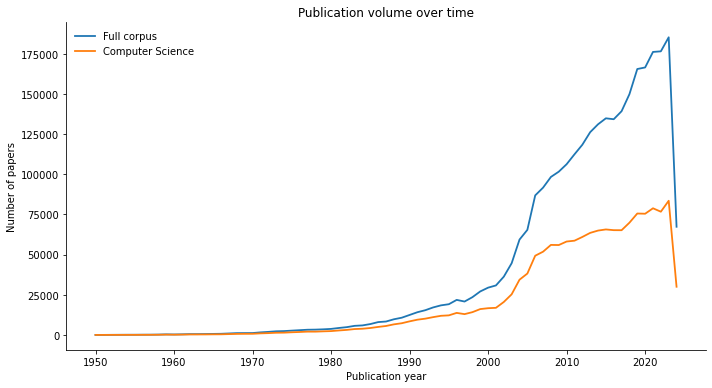

In [5]:
year_counts = (
    publication_year
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

cs_year_counts = (
    publication_year[cs_mask]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(
    year_counts.index,
    year_counts.values,
    linewidth=1.8,
    label="Full corpus"
)

if N_CS < 0.995 * N:
    ax.plot(
        cs_year_counts.index,
        cs_year_counts.values,
        linewidth=1.8,
        label="Computer Science"
    )
    ax.legend(frameon=False)

ax.set_xlabel("Publication year")
ax.set_ylabel("Number of papers")
ax.set_title("Publication volume over time")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "eda_publications_over_time.pdf",
    bbox_inches="tight"
)
plt.savefig(
    FIG_DIR / "eda_publications_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Figure 5.2 - Gender-metadata coverage over time

,first_known,last_known,complete_known
decade,,,
1950,79.97,80.12,77.09
1960,80.28,78.61,75.83
1970,83.59,82.83,78.50
1980,86.45,86.44,80.82
1990,86.21,86.80,79.42
2000,83.19,85.07,74.42
2010,79.98,82.36,69.32
2020,75.66,77.52,61.88


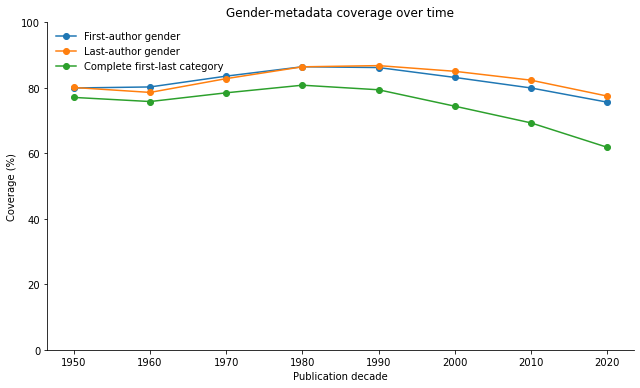

In [6]:
gender_time = pd.DataFrame({
    "decade": decade,
    "first_known": first_gender_known.astype(int),
    "last_known": last_gender_known.astype(int),
    "complete_known": complete_gender_known.astype(int),
    "is_cs": cs_mask.astype(int)
})

if N_CS > 0:
    gender_time_plot = gender_time[
        gender_time["is_cs"] == 1
    ].copy()
else:
    gender_time_plot = gender_time.copy()

gender_coverage_by_decade = (
    gender_time_plot
    .dropna(subset=["decade"])
    .groupby("decade")[
        ["first_known", "last_known", "complete_known"]
    ]
    .mean()
    .mul(100)
)

display((gender_coverage_by_decade).round(2))

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(
    gender_coverage_by_decade.index,
    gender_coverage_by_decade["first_known"],
    marker="o",
    label="First-author gender"
)

ax.plot(
    gender_coverage_by_decade.index,
    gender_coverage_by_decade["last_known"],
    marker="o",
    label="Last-author gender"
)

ax.plot(
    gender_coverage_by_decade.index,
    gender_coverage_by_decade["complete_known"],
    marker="o",
    label="Complete first-last category"
)

ax.set_xlabel("Publication decade")
ax.set_ylabel("Coverage (%)")
ax.set_ylim(0, 100)
ax.set_title("Gender-metadata coverage over time")
ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "eda_gender_coverage_by_decade.pdf",
    bbox_inches="tight"
)
plt.savefig(
    FIG_DIR / "eda_gender_coverage_by_decade.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

gender_coverage_by_decade.to_csv(
    TABLE_DIR / "eda_gender_coverage_by_decade.csv"
)

# 5.2 Authorship, Gender, and Reference Characteristics

Only the tables, descriptive summaries, and final figure versions used in Section 5.2 are retained.
Alternative early versions of the same plots and the unused median-by-gender figures are omitted.

## Table 5.3 - First–last author gender composition

In [7]:
def gender_composition_table(data, label):
    counts = (
        data["first_last_cat"]
        .value_counts()
        .reindex(KNOWN_CATEGORIES)
        .fillna(0)
        .astype(int)
    )

    shares = 100 * counts / counts.sum()

    out = pd.DataFrame({
        "sample": label,
        "category": KNOWN_CATEGORIES,
        "count": counts.values,
        "share_among_known_pct": shares.values
    })

    return out

gender_full = gender_composition_table(df_known, "Full corpus")
gender_cs = gender_composition_table(df_cs_known, "Computer Science")

gender_composition = pd.concat(
    [gender_full, gender_cs],
    ignore_index=True
)

display(gender_composition.round(2))

gender_composition.to_csv(
    TABLE_DIR / "eda_first_last_gender_composition_full_vs_cs.csv",
    index=False
)

,sample,category,count,share_among_known_pct
0,Full corpus,MM,1506965,71.42
1,Full corpus,MW,196542,9.31
2,Full corpus,WM,284457,13.48
3,Full corpus,WW,122057,5.78
4,Computer Science,MM,790617,73.11
5,Computer Science,MW,97399,9.01
6,Computer Science,WM,137756,12.74
7,Computer Science,WW,55591,5.14


## Figure 5.3 - First–last gender composition: full corpus vs Computer Science

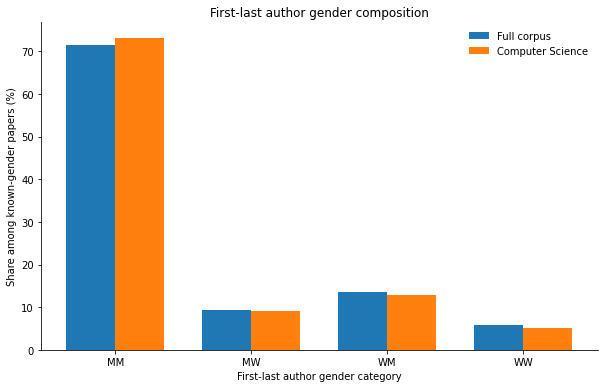

In [8]:
plot_table = (
    gender_composition
    .pivot(
        index="category",
        columns="sample",
        values="share_among_known_pct"
    )
    .reindex(KNOWN_CATEGORIES)
)

x = np.arange(len(KNOWN_CATEGORIES))
width = 0.36

fig, ax = plt.subplots(figsize=(8.5, 5.5))

ax.bar(
    x - width / 2,
    plot_table["Full corpus"].values,
    width,
    label="Full corpus"
)

ax.bar(
    x + width / 2,
    plot_table["Computer Science"].values,
    width,
    label="Computer Science"
)

ax.set_xticks(x)
ax.set_xticklabels(KNOWN_CATEGORIES)

ax.set_xlabel("First-last author gender category")
ax.set_ylabel("Share among known-gender papers (%)")
ax.set_title("First-last author gender composition")
ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "eda_first_last_gender_composition_full_vs_cs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIGURE_DIR / "eda_first_last_gender_composition_full_vs_cs.pdf",
    bbox_inches="tight"
)

plt.show()

## Table 5.4 - Gender composition over time

In [9]:
def gender_by_decade(data):
    return (
        pd.crosstab(
            data["decade"],
            data["first_last_cat"],
            normalize="index"
        )
        .reindex(columns=KNOWN_CATEGORIES, fill_value=0)
        .mul(100)
        .round(2)
    )

gender_by_decade_full = gender_by_decade(df_known)
gender_by_decade_cs = gender_by_decade(df_cs_known)

print("Full corpus - category shares by decade (%)")
display(gender_by_decade_full)

print("Computer Science - category shares by decade (%)")
display(gender_by_decade_cs)

gender_by_decade_full.to_csv(
    TABLE_DIR / "eda_gender_composition_by_decade_full.csv"
)

gender_by_decade_cs.to_csv(
    TABLE_DIR / "eda_gender_composition_by_decade_cs.csv"
)

Full corpus - category shares by decade (%)


first_last_cat,MM,MW,WM,WW
decade,,,,
1950,95.94,1.39,0.53,2.14
1960,96.20,0.85,0.57,2.39
1970,93.46,1.71,1.53,3.30
1980,87.78,3.62,3.76,4.84
1990,82.57,5.70,6.75,4.98
2000,75.75,8.18,10.98,5.09
2010,69.87,9.93,14.47,5.73
2020,63.60,11.43,17.90,7.07


Computer Science - category shares by decade (%)


first_last_cat,MM,MW,WM,WW
decade,,,,
1950,96.65,1.38,0.00,1.97
1960,95.76,1.03,0.63,2.57
1970,93.00,1.84,1.66,3.49
1980,87.42,3.86,3.92,4.80
1990,82.71,5.81,6.77,4.71
2000,76.51,8.21,10.78,4.50
2010,71.13,9.76,14.00,5.10
2020,64.74,11.27,17.56,6.42


## Figure 5.4 - Gender composition over time in Computer Science

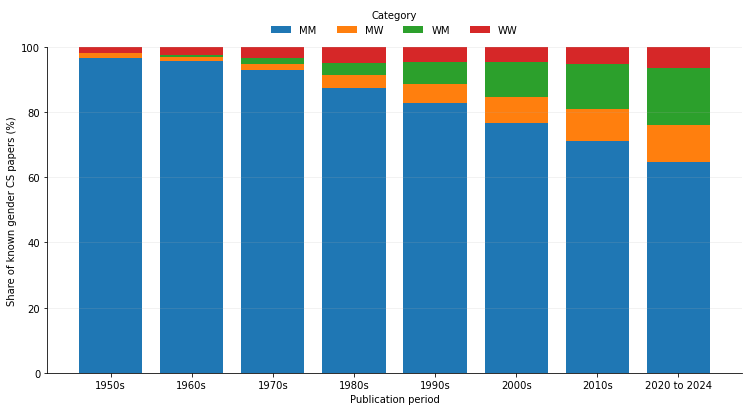

In [10]:
gender_shares_time = gender_by_decade_cs.copy()

period_labels = [
    "2020 to 2024" if int(d) == 2020 else f"{int(d)}s"
    for d in gender_shares_time.index
]

fig, ax = plt.subplots(figsize=(10.5, 5.8))
bottom = np.zeros(len(gender_shares_time))

for category in KNOWN_CATEGORIES:
    values = gender_shares_time[category].values
    ax.bar(
        period_labels,
        values,
        bottom=bottom,
        width=0.78,
        label=category
    )
    bottom += values

ax.set_xlabel("Publication period")
ax.set_ylabel("Share of known gender CS papers (%)")
ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 20))

ax.legend(
    title="Category",
    ncol=4,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.14)
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "eda_gender_composition_over_time_cs_stacked.png",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    FIGURE_DIR / "eda_gender_composition_over_time_cs_stacked.pdf",
    bbox_inches="tight"
)

plt.show()

## Authorship-team size summary

In [11]:
author_summary_full = df["n_authors"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
)

author_summary_cs = df_cs["n_authors"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
)

authorship_summary = pd.DataFrame({
    "Full corpus": author_summary_full,
    "Computer Science": author_summary_cs
})

display(authorship_summary.round(2))

authorship_summary.to_csv(
    TABLE_DIR / "eda_authorship_size_summary_full_vs_cs.csv"
)

,Full corpus,Computer Science
count,3026412.00,1542691.00
mean,3.26,3.15
std,1.80,1.66
min,1.00,1.00
25%,2.00,2.00
50%,3.00,3.00
75%,4.00,4.00
90%,5.00,5.00
95%,6.00,6.00
99%,9.00,8.00


## Figure 5.5 - Authorship-team size in Computer Science

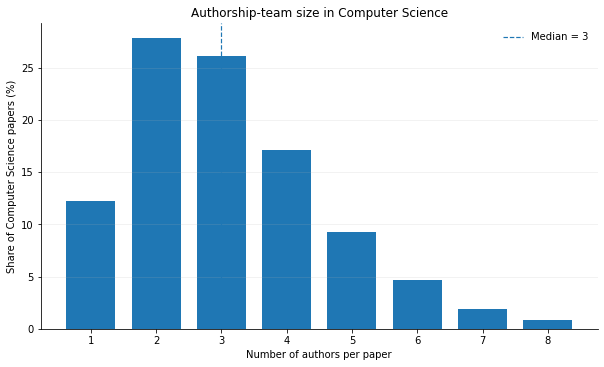

Median authorship size: 3
99th percentile: 8
Top 1% of the authorship-size distribution omitted from the figure.


In [12]:
author_p99 = int(df_cs["n_authors"].quantile(0.99))
author_median = df_cs["n_authors"].median()


author_plot = df_cs.loc[
    df_cs["n_authors"].between(1, author_p99),
    "n_authors"
].dropna().astype(int)

author_dist = (
    author_plot
    .value_counts()
    .sort_index()
)

author_pct = 100 * author_dist / len(author_plot)

fig, ax = plt.subplots(figsize=(8.5, 5.2))

ax.bar(
    author_pct.index,
    author_pct.values,
    width=0.75
)

ax.axvline(
    author_median,
    linestyle="--",
    linewidth=1.2,
    label=f"Median = {author_median:.0f}"
)

ax.set_xticks(range(1, author_p99 + 1))

ax.set_xlabel("Number of authors per paper")
ax.set_ylabel("Share of Computer Science papers (%)")
ax.set_title("Authorship-team size in Computer Science")

ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "eda_authorship_size_distribution_cs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIGURE_DIR / "eda_authorship_size_distribution_cs.pdf",
    bbox_inches="tight"
)

plt.show()

print(f"Median authorship size: {author_median:.0f}")
print(f"99th percentile: {author_p99}")
print("Top 1% of the authorship-size distribution omitted from the figure.")

## Reference-list length summary

In [13]:
ref_summary_full = df["n_refs"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
)

ref_summary_cs = df_cs["n_refs"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
)

reference_summary = pd.DataFrame({
    "Full corpus": ref_summary_full,
    "Computer Science": ref_summary_cs
})

display(reference_summary.round(2))

reference_summary.to_csv(
    TABLE_DIR / "eda_reference_list_summary_full_vs_cs.csv"
)

,Full corpus,Computer Science
count,3026412.00,1542691.00
mean,7.53,8.59
std,7.63,8.20
min,0.00,0.00
25%,2.00,3.00
50%,6.00,7.00
75%,10.00,12.00
90%,16.00,18.00
95%,21.00,22.00
99%,32.00,34.00


## Figure 5.6 - Reference-list length in Computer Science

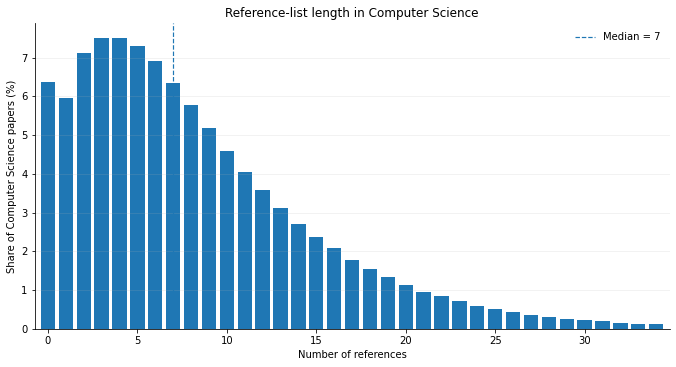

Median reference-list length: 7
99th percentile: 34
Top 1% of the reference-list distribution omitted from the figure.


In [14]:
ref_p99_cs = int(df_cs["n_refs"].quantile(0.99))
ref_median_cs = df_cs["n_refs"].median()


ref_plot = df_cs.loc[
    df_cs["n_refs"].between(0, ref_p99_cs),
    "n_refs"
].dropna().astype(int)

ref_dist = (
    ref_plot
    .value_counts()
    .reindex(
        range(0, ref_p99_cs + 1),
        fill_value=0
    )
)

ref_pct = 100 * ref_dist / len(ref_plot)

fig, ax = plt.subplots(figsize=(9.5, 5.2))

ax.bar(
    ref_pct.index,
    ref_pct.values,
    width=0.8
)

ax.axvline(
    ref_median_cs,
    linestyle="--",
    linewidth=1.2,
    label=f"Median = {ref_median_cs:.0f}"
)

ax.set_xlim(-0.75, ref_p99_cs + 0.75)

ax.set_xticks(
    np.arange(
        0,
        ref_p99_cs + 1,
        5
    )
)

ax.set_xlabel("Number of references")
ax.set_ylabel("Share of Computer Science papers (%)")
ax.set_title("Reference-list length in Computer Science")

ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "eda_reference_list_length_distribution_cs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIGURE_DIR / "eda_reference_list_length_distribution_cs.pdf",
    bbox_inches="tight"
)

plt.show()

print(f"Median reference-list length: {ref_median_cs:.0f}")
print(f"99th percentile: {ref_p99_cs}")
print("Top 1% of the reference-list distribution omitted from the figure.")

## Table 5.5 - Authorship and reference characteristics by gender category

In [15]:
def descriptive_row(data, sample, category):
    return {
        "sample": sample,
        "category": category,
        "n": len(data),

        "authors_mean": data["n_authors"].mean(),
        "authors_median": data["n_authors"].median(),
        "authors_p75": data["n_authors"].quantile(0.75),
        "authors_p90": data["n_authors"].quantile(0.90),
        "authors_p99": data["n_authors"].quantile(0.99),

        "refs_mean": data["n_refs"].mean(),
        "refs_median": data["n_refs"].median(),
        "refs_p75": data["n_refs"].quantile(0.75),
        "refs_p90": data["n_refs"].quantile(0.90),
        "refs_p99": data["n_refs"].quantile(0.99),

        "zero_refs_pct": 100 * data["n_refs"].eq(0).mean()
    }


rows = [
    descriptive_row(df, "Full corpus", "All papers"),
    descriptive_row(df_cs, "Computer Science", "All papers"),
]

for category in KNOWN_CATEGORIES:
    subset = df_cs_known[
        df_cs_known["first_last_cat"].eq(category)
    ]

    rows.append(
        descriptive_row(
            subset,
            "Computer Science",
            category
        )
    )

auth_ref_by_gender = pd.DataFrame(rows)

display(auth_ref_by_gender.round(2))

auth_ref_by_gender.to_csv(
    TABLE_DIR / "eda_authorship_reference_characteristics_by_gender_cs.csv",
    index=False
)

,sample,category,n,authors_mean,authors_median,authors_p75,authors_p90,authors_p99,refs_mean,refs_median,refs_p75,refs_p90,refs_p99,zero_refs_pct
0,Full corpus,All papers,3026412,3.26,3.0,4.0,5.0,9.0,7.53,6.0,10.0,16.0,32.0,7.78
1,Computer Science,All papers,1542691,3.15,3.0,4.0,5.0,8.0,8.59,7.0,12.0,18.0,34.0,6.30
2,Computer Science,MM,790617,2.93,3.0,4.0,5.0,8.0,8.16,6.0,11.0,17.0,34.0,7.49
3,Computer Science,MW,97399,3.39,3.0,4.0,5.0,8.0,8.68,7.0,12.0,18.0,34.0,5.42
4,Computer Science,WM,137756,3.43,3.0,4.0,5.0,8.0,8.94,7.0,12.0,18.0,35.0,4.92
5,Computer Science,WW,55591,2.48,2.0,3.0,5.0,8.0,7.53,6.0,10.0,16.0,34.0,8.48


## Figure 5.7 - Reference-list length over time in Computer Science

Final analytical papers: 3,026,412
CS papers used for reference analysis: 1,542,691
Papers with valid n_refs: 1,542,691

Reference list characteristics by decade


,n,mean,median,p75,p90,p99
decade,,,,,,
1950,659,0.81,0.0,1.0,2.0,4.42
1960,3951,2.20,1.0,3.0,5.0,11.50
1970,15462,3.19,2.0,4.0,8.0,18.00
1980,44581,4.50,3.0,6.0,11.0,23.00
1990,120230,6.10,4.0,9.0,14.0,28.00
2000,365164,6.74,5.0,9.0,14.0,28.00
2010,648014,9.21,7.0,12.0,19.0,35.00
2020,344630,11.11,9.0,15.0,21.0,40.00


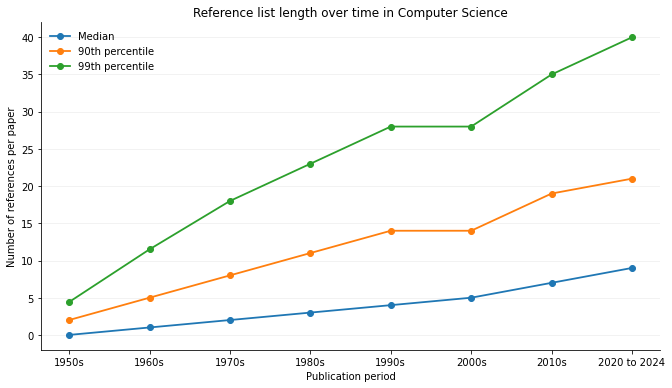

In [16]:
df_cs_refs_plot = df[
    df["primary_field"].eq("Computer Science")
].copy()

print(f"Final analytical papers: {len(df):,}")
print(f"CS papers used for reference analysis: {len(df_cs_refs_plot):,}")



df_cs_refs_plot["n_refs"] = pd.to_numeric(
    df_cs_refs_plot["n_refs"],
    errors="coerce"
)

print(
    f"Papers with valid n_refs: "
    f"{df_cs_refs_plot['n_refs'].notna().sum():,}"
)


refs_by_decade = (
    df_cs_refs_plot
    .dropna(subset=["decade", "n_refs"])
    .groupby("decade")["n_refs"]
    .agg(
        n="size",
        mean="mean",
        median="median",
        p75=lambda x: x.quantile(0.75),
        p90=lambda x: x.quantile(0.90),
        p99=lambda x: x.quantile(0.99)
    )
    .sort_index()
)

print("\nReference list characteristics by decade")
display(refs_by_decade.round(2))


fig, ax = plt.subplots(figsize=(9.5, 5.5))

ax.plot(
    refs_by_decade.index,
    refs_by_decade["median"],
    marker="o",
    linewidth=1.8,
    label="Median"
)

ax.plot(
    refs_by_decade.index,
    refs_by_decade["p90"],
    marker="o",
    linewidth=1.8,
    label="90th percentile"
)

ax.plot(
    refs_by_decade.index,
    refs_by_decade["p99"],
    marker="o",
    linewidth=1.8,
    label="99th percentile"
)

period_labels = [
    "2020 to 2024" if int(x) == 2020 else f"{int(x)}s"
    for x in refs_by_decade.index
]

ax.set_xticks(refs_by_decade.index)
ax.set_xticklabels(
    period_labels,
    rotation=0
)

ax.set_xlabel("Publication period")
ax.set_ylabel("Number of references per paper")
ax.set_title("Reference list length over time in Computer Science")

ax.legend(
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "eda_references_per_cs_paper_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIGURE_DIR / "eda_references_per_cs_paper_over_time.pdf",
    bbox_inches="tight"
)

plt.show()

# 5.3 Venue and Taxonomy Composition

This section retains the venue and taxonomy diagnostics that directly support the text, tables,
and figures in Section 5.3.

## Table 5.6 - Venue metadata coverage

In [17]:
def present_string(s):
    return (
        s.notna()
        & s.astype(str).str.strip().ne("")
        & ~s.astype(str).str.strip().str.lower().isin(
            ["nan", "none", "null", "n/a", "na", "unknown", "missing"]
        )
    )

venue_name_available = present_string(df_cs["venue_name"])
venue_type_available = present_string(df_cs["venue_type"])


venue_rank_available = (
    df_cs["venue_rank_clean"].notna()
    & df_cs["venue_rank_clean"].astype(str).str.strip().ne("")
    & ~df_cs["venue_rank_clean"].astype(str).str.strip().str.upper().eq("N/A")
)

venue_coverage = pd.DataFrame({
    "Variable": [
        "Venue name",
        "Venue type",
        "Venue rank"
    ],
    "Available N": [
        int(venue_name_available.sum()),
        int(venue_type_available.sum()),
        int(venue_rank_available.sum())
    ]
})

venue_coverage["Missing N"] = len(df_cs) - venue_coverage["Available N"]
venue_coverage["Coverage (%)"] = (
    100 * venue_coverage["Available N"] / len(df_cs)
)
venue_coverage["Missing (%)"] = (
    100 * venue_coverage["Missing N"] / len(df_cs)
)

display(venue_coverage.round(2))

venue_coverage.to_csv(
    TABLE_DIR / "eda_cs_venue_metadata_coverage.csv",
    index=False
)

,Variable,Available N,Missing N,Coverage (%),Missing (%)
0,Venue name,1542691,0,100.00,0.00
1,Venue type,1542691,0,100.00,0.00
2,Venue rank,879692,662999,57.02,42.98


## Figure 5.8 - Venue type composition

In [18]:
venue_type_cs = (
    df_cs["venue_type"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .replace({
        "": "Unknown",
        "nan": "Unknown",
        "None": "Unknown",
        "N/A": "Unknown"
    })
    .value_counts()
)

venue_type_summary_cs = pd.DataFrame({
    "count": venue_type_cs,
    "share_pct": 100 * venue_type_cs / len(df_cs)
})

display(venue_type_summary_cs.round(2))

venue_type_summary_cs.to_csv(
    TABLE_DIR / "eda_cs_venue_type_distribution.csv"
)

,count,share_pct
inproceedings,878816,56.97
journal,663875,43.03


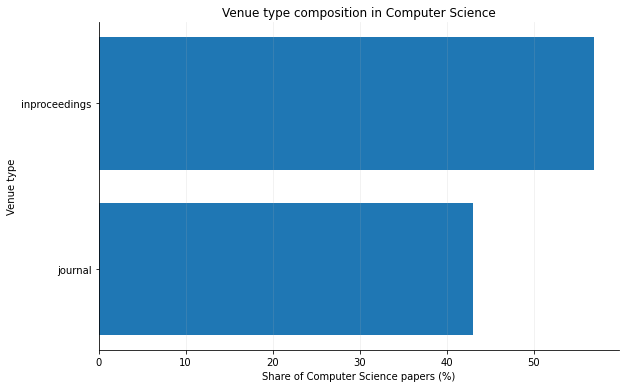

In [19]:
plot_type = venue_type_summary_cs.head(12).sort_values("share_pct")

fig, ax = plt.subplots(figsize=(8.8, 5.5))

ax.barh(
    plot_type.index,
    plot_type["share_pct"]
)

ax.set_xlabel("Share of Computer Science papers (%)")
ax.set_ylabel("Venue type")
ax.set_title("Venue type composition in Computer Science")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "eda_cs_venue_type_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIGURE_DIR / "eda_cs_venue_type_distribution.pdf",
    bbox_inches="tight"
)

plt.show()

## Figure 5.9 - Venue-rank composition

In [20]:
rank_order = ["A*", "A", "B", "C", "Q1", "Q2", "Q3", "Q4", "N/A"]

venue_rank_cs = (
    df_cs["venue_rank_clean"]
    .fillna("N/A")
    .astype(str)
    .replace({"": "N/A"})
    .value_counts()
    .reindex(rank_order, fill_value=0)
)

venue_rank_summary_cs = pd.DataFrame({
    "count": venue_rank_cs,
    "share_pct": 100 * venue_rank_cs / len(df_cs)
})

display(venue_rank_summary_cs.round(2))

venue_rank_summary_cs.to_csv(
    TABLE_DIR / "eda_cs_venue_rank_distribution.csv"
)

,count,share_pct
A*,108898,7.06
A,87358,5.66
B,138748,8.99
C,53716,3.48
Q1,270341,17.52
Q2,131991,8.56
Q3,71999,4.67
Q4,16641,1.08
N/A,662999,42.98


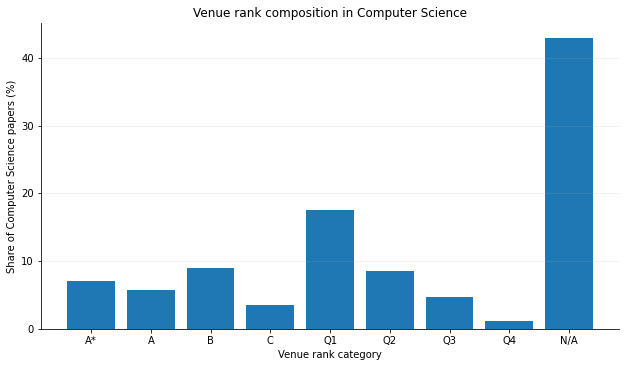

In [21]:
fig, ax = plt.subplots(figsize=(8.8, 5.2))

ax.bar(
    venue_rank_summary_cs.index,
    venue_rank_summary_cs["share_pct"]
)

ax.set_xlabel("Venue rank category")
ax.set_ylabel("Share of Computer Science papers (%)")
ax.set_title("Venue rank composition in Computer Science")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "eda_cs_venue_rank_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIGURE_DIR / "eda_cs_venue_rank_distribution.pdf",
    bbox_inches="tight"
)

plt.show()

## Individual venue concentration used in the text

In [22]:
top_venues_cs = (
    df_cs["venue_name"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
    .replace({"": "Unknown"})
    .value_counts()
    .head(20)
    .rename("count")
    .to_frame()
)

top_venues_cs["share_pct"] = 100 * top_venues_cs["count"] / len(df_cs)

display(top_venues_cs.round(2))

top_venues_cs.to_csv(
    TABLE_DIR / "eda_cs_top_venues.csv"
)

,count,share_pct
ieee access,23125,1.50
corr,18533,1.20
icassp,17700,1.15
aaai,10860,0.70
icip,10493,0.68
sensors,9125,0.59
interspeech,8689,0.56
cvpr,8079,0.52
icc,7800,0.51
theor. comput. sci.,7658,0.50


## Table 5.7 and Figure 5.10 - Computer Science taxonomy composition

In [23]:
subfield_counts_cs = (
    df_cs["primary_subfield"]
    .fillna("Unknown")
    .astype(str)
    .value_counts()
)

subfield_summary_cs = pd.DataFrame({
    "count": subfield_counts_cs,
    "share_pct": 100 * subfield_counts_cs / len(df_cs)
})

topic_counts_cs = (
    df_cs["primary_topic_name"]
    .fillna("Unknown")
    .astype(str)
    .value_counts()
)

topic_summary_cs = pd.DataFrame({
    "count": topic_counts_cs,
    "share_pct": 100 * topic_counts_cs / len(df_cs)
})

print(f"Unique CS subfields: {df_cs['primary_subfield'].nunique(dropna=True):,}")
print(f"Unique CS primary topics: {df_cs['primary_topic_name'].nunique(dropna=True):,}")

print("\nTop Computer Science subfields")
display((subfield_summary_cs.head(20)).round(2))

print("\nTop Computer Science topics")
display((topic_summary_cs.head(20)).round(2))

subfield_summary_cs.to_csv(
    TABLE_DIR / "eda_cs_subfield_distribution.csv"
)

topic_summary_cs.to_csv(
    TABLE_DIR / "eda_cs_topic_distribution.csv"
)

Unique CS subfields: 11
Unique CS primary topics: 301

Top Computer Science subfields


,count,share_pct
Artificial Intelligence,404721,26.23
Computer Networks and Communications,319111,20.69
Computer Vision and Pattern Recognition,277979,18.02
Information Systems,154868,10.04
Computational Theory and Mathematics,109785,7.12
Signal Processing,92791,6.01
Hardware and Architecture,75691,4.91
Human-Computer Interaction,35561,2.31
Computer Science Applications,24663,1.60
Software,23790,1.54



Top Computer Science topics


,count,share_pct
Parallel Computing and Performance Optimization,36133,2.34
Statistical Machine Translation and Natural Language Processing,34311,2.22
Empirical Studies in Software Engineering,23624,1.53
Natural Language Processing,22275,1.44
Stereo Vision and Depth Estimation,21589,1.40
Wireless Sensor Networks: Survey and Applications,20248,1.31
Semantic Web and Ontology Development,19748,1.28
Cloud Computing and Big Data Technologies,19462,1.26
Cooperative Diversity in Wireless Networks,19223,1.25
Image Feature Retrieval and Recognition Techniques,18553,1.20


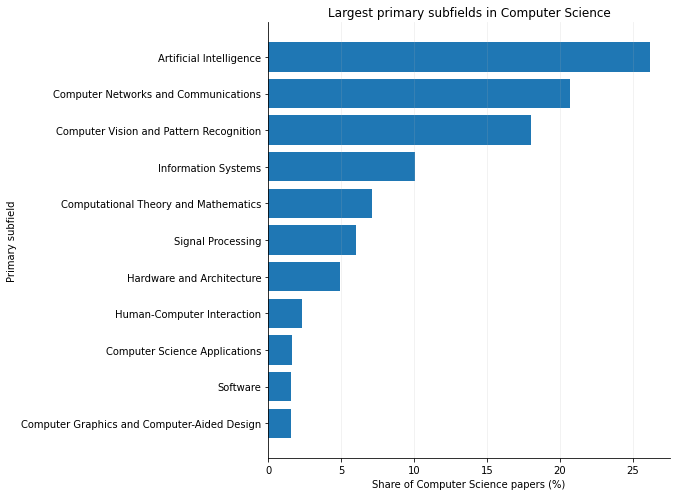

In [24]:
TOP_N_SUBFIELDS = 15

subfield_plot = (
    subfield_summary_cs
    .head(TOP_N_SUBFIELDS)
    .sort_values("share_pct")
)

fig, ax = plt.subplots(figsize=(9.5, 7.0))

ax.barh(
    subfield_plot.index,
    subfield_plot["share_pct"]
)

ax.set_xlabel("Share of Computer Science papers (%)")
ax.set_ylabel("Primary subfield")
ax.set_title("Largest primary subfields in Computer Science")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "eda_cs_top_subfields.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIGURE_DIR / "eda_cs_top_subfields.pdf",
    bbox_inches="tight"
)

plt.show()

### Taxonomy concentration statistics used in the text

In [25]:
taxonomy_concentration = pd.DataFrame({
    "Measure": [
        "Largest subfield share (%)",
        "Top 3 subfields share (%)",
        "Top 5 subfields share (%)",
        "Top 10 subfields share (%)",
        "Largest topic share (%)",
        "Top 5 topics share (%)",
        "Top 10 topics share (%)",
        "Top 20 topics share (%)"
    ],
    "Value": [
        subfield_summary_cs["share_pct"].iloc[0],
        subfield_summary_cs["share_pct"].head(3).sum(),
        subfield_summary_cs["share_pct"].head(5).sum(),
        subfield_summary_cs["share_pct"].head(10).sum(),
        topic_summary_cs["share_pct"].iloc[0],
        topic_summary_cs["share_pct"].head(5).sum(),
        topic_summary_cs["share_pct"].head(10).sum(),
        topic_summary_cs["share_pct"].head(20).sum(),
    ]
})

display(taxonomy_concentration.round(2))

taxonomy_concentration.to_csv(
    TABLE_DIR / "eda_cs_taxonomy_concentration.csv",
    index=False
)

,Measure,Value
0,Largest subfield share (%),26.23
1,Top 3 subfields share (%),64.94
2,Top 5 subfields share (%),82.09
3,Top 10 subfields share (%),98.46
4,Largest topic share (%),2.34
5,Top 5 topics share (%),8.94
6,Top 10 topics share (%),15.24
7,Top 20 topics share (%),26.08


## Table 5.8 and Figure 5.11 - Gender composition across venue-rank categories

In [26]:
venue_rank_gender_counts_cs = pd.crosstab(
    df_cs_known["venue_rank_clean"].fillna("N/A"),
    df_cs_known["first_last_cat"]
).reindex(columns=KNOWN_CATEGORIES, fill_value=0)

venue_rank_gender_shares_cs = (
    pd.crosstab(
        df_cs_known["venue_rank_clean"].fillna("N/A"),
        df_cs_known["first_last_cat"],
        normalize="index"
    )
    .reindex(columns=KNOWN_CATEGORIES, fill_value=0)
    .mul(100)
)

venue_rank_gender_counts_cs = venue_rank_gender_counts_cs.reindex(
    rank_order,
    fill_value=0
)

venue_rank_gender_shares_cs = venue_rank_gender_shares_cs.reindex(
    rank_order,
    fill_value=0
)

print("Known gender sample size by venue rank")
display(venue_rank_gender_counts_cs)

print("Gender composition within venue rank (%)")
display((venue_rank_gender_shares_cs).round(2))

venue_rank_gender_counts_cs.to_csv(
    TABLE_DIR / "eda_cs_gender_counts_by_venue_rank.csv"
)

venue_rank_gender_shares_cs.to_csv(
    TABLE_DIR / "eda_cs_gender_shares_by_venue_rank.csv"
)

Known gender sample size by venue rank


first_last_cat,MM,MW,WM,WW
venue_rank_clean,,,,
A*,59153,6617,8442,2950
A,47709,5952,8006,3176
B,69366,8963,13302,3920
C,27039,3982,5899,2344
Q1,131800,14884,22162,7452
Q2,66132,8165,11360,5279
Q3,35170,3950,6066,2926
Q4,8443,932,1395,770
N/A,345805,43954,61124,26774


Gender composition within venue rank (%)


first_last_cat,MM,MW,WM,WW
venue_rank_clean,,,,
A*,76.66,8.58,10.94,3.82
A,73.58,9.18,12.35,4.90
B,72.60,9.38,13.92,4.10
C,68.86,10.14,15.02,5.97
Q1,74.76,8.44,12.57,4.23
Q2,72.72,8.98,12.49,5.81
Q3,73.10,8.21,12.61,6.08
Q4,73.16,8.08,12.09,6.67
N/A,72.40,9.20,12.80,5.61


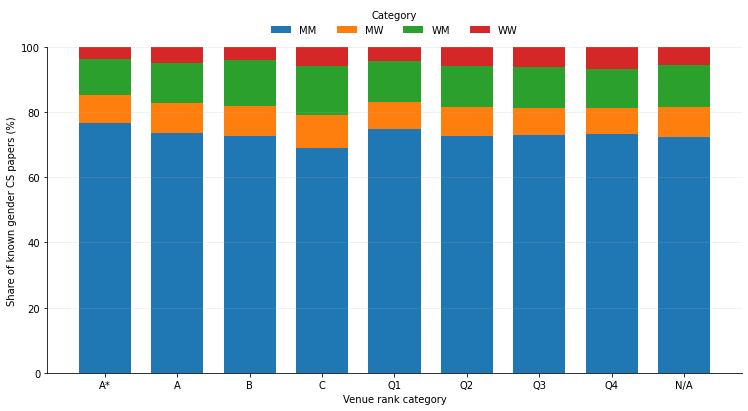

In [27]:
plot_rank_gender = venue_rank_gender_shares_cs.loc[
    venue_rank_gender_shares_cs.sum(axis=1) > 0,
    KNOWN_CATEGORIES
]

fig, ax = plt.subplots(figsize=(10.5, 5.8))

bottom = np.zeros(len(plot_rank_gender))

for category in KNOWN_CATEGORIES:
    values = plot_rank_gender[category].values

    ax.bar(
        plot_rank_gender.index,
        values,
        bottom=bottom,
        width=0.72,
        label=category
    )

    bottom += values

ax.set_xlabel("Venue rank category")
ax.set_ylabel("Share of known gender CS papers (%)")

ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 20))


ax.legend(
    title="Category",
    ncol=4,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.14)
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "eda_cs_gender_composition_by_venue_rank.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIGURE_DIR / "eda_cs_gender_composition_by_venue_rank.pdf",
    bbox_inches="tight"
)

plt.show()

## Venue-type gender composition used in the text

In [28]:
venue_type_gender_counts_cs = pd.crosstab(
    df_cs_known["venue_type"].fillna("Unknown"),
    df_cs_known["first_last_cat"]
).reindex(columns=KNOWN_CATEGORIES, fill_value=0)

venue_type_gender_shares_cs = (
    pd.crosstab(
        df_cs_known["venue_type"].fillna("Unknown"),
        df_cs_known["first_last_cat"],
        normalize="index"
    )
    .reindex(columns=KNOWN_CATEGORIES, fill_value=0)
    .mul(100)
)

venue_type_sample_sizes = venue_type_gender_counts_cs.sum(axis=1)

MIN_VENUE_TYPE_N = 1000

valid_venue_types = venue_type_sample_sizes[
    venue_type_sample_sizes >= MIN_VENUE_TYPE_N
].sort_values(ascending=False).index

print(
    f"Venue types with at least {MIN_VENUE_TYPE_N:,} "
    f"known gender CS papers: {len(valid_venue_types)}"
)

display((venue_type_gender_shares_cs.loc[valid_venue_types]).round(2))

venue_type_gender_counts_cs.to_csv(
    TABLE_DIR / "eda_cs_gender_counts_by_venue_type.csv"
)

venue_type_gender_shares_cs.to_csv(
    TABLE_DIR / "eda_cs_gender_shares_by_venue_type.csv"
)

Venue types with at least 1,000 known gender CS papers: 2


first_last_cat,MM,MW,WM,WW
venue_type,,,,
inproceedings,72.19,9.45,13.33,5.03
journal,74.39,8.39,11.92,5.29


## Table 5.9 and Figure 5.12 - Gender composition across Computer Science subfields

In [29]:
subfield_gender_counts_cs = pd.crosstab(
    df_cs_known["primary_subfield"],
    df_cs_known["first_last_cat"]
).reindex(columns=KNOWN_CATEGORIES, fill_value=0)

subfield_gender_shares_cs = (
    pd.crosstab(
        df_cs_known["primary_subfield"],
        df_cs_known["first_last_cat"],
        normalize="index"
    )
    .reindex(columns=KNOWN_CATEGORIES, fill_value=0)
    .mul(100)
)

subfield_known_n = subfield_gender_counts_cs.sum(axis=1)

MIN_SUBFIELD_N = 5000

valid_subfields = (
    subfield_known_n[
        subfield_known_n >= MIN_SUBFIELD_N
    ]
    .sort_values(ascending=False)
    .index
)

subfield_gender_summary_cs = (
    subfield_gender_shares_cs
    .loc[valid_subfields]
    .copy()
)

subfield_gender_summary_cs.insert(
    0,
    "known_gender_n",
    subfield_known_n.loc[valid_subfields]
)

print(
    f"CS subfields with at least {MIN_SUBFIELD_N:,} "
    f"known gender papers: {len(valid_subfields)}"
)

display(subfield_gender_summary_cs.round(2))

subfield_gender_summary_cs.to_csv(
    TABLE_DIR / "eda_cs_gender_composition_by_subfield_filtered.csv"
)

CS subfields with at least 5,000 known gender papers: 11


first_last_cat,known_gender_n,MM,MW,WM,WW
primary_subfield,,,,,
Artificial Intelligence,293814,71.79,9.51,12.90,5.80
Computer Networks and Communications,214586,75.46,8.60,12.38,3.55
Computer Vision and Pattern Recognition,174459,72.93,9.19,13.90,3.98
Information Systems,111061,66.78,10.52,14.84,7.86
Computational Theory and Mathematics,84168,78.60,7.27,9.20,4.93
Signal Processing,62022,75.62,8.22,12.66,3.50
Hardware and Architecture,56693,81.89,6.55,9.19,2.37
Human-Computer Interaction,27954,59.51,11.60,17.14,11.74
Computer Science Applications,19593,57.65,11.68,16.81,13.86


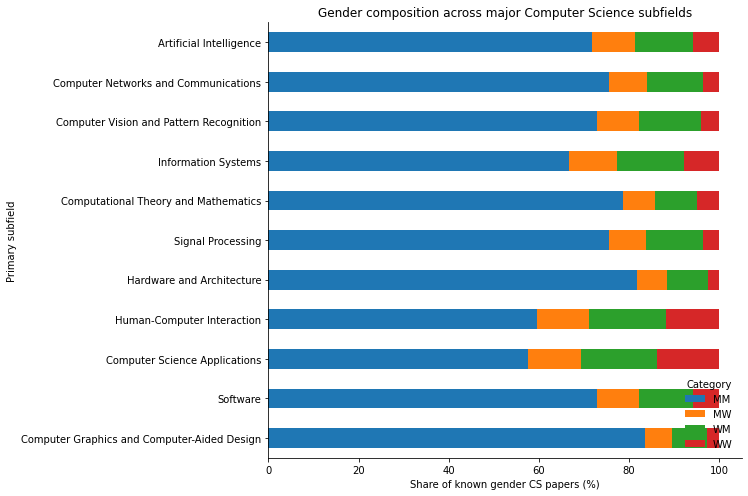

In [30]:
TOP_N_SUBFIELDS_GENDER = 12

largest_subfields_for_gender = (
    subfield_known_n
    .sort_values(ascending=False)
    .head(TOP_N_SUBFIELDS_GENDER)
    .index
)

plot_subfield_gender = (
    subfield_gender_shares_cs
    .loc[largest_subfields_for_gender, KNOWN_CATEGORIES]
    .iloc[::-1]
)

ax = plot_subfield_gender.plot(
    kind="barh",
    stacked=True,
    figsize=(10.5, 7.0)
)

ax.set_xlabel("Share of known gender CS papers (%)")
ax.set_ylabel("Primary subfield")
ax.set_title("Gender composition across major Computer Science subfields")

plt.legend(
    title="Category",
    frameon=False,
    loc="lower right"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "eda_cs_gender_composition_major_subfields.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIGURE_DIR / "eda_cs_gender_composition_major_subfields.pdf",
    bbox_inches="tight"
)

plt.show()

### Subfield variation used in the discussion of Table 5.9

In [31]:
subfield_gender_variation = (
    subfield_gender_shares_cs
    .loc[valid_subfields, KNOWN_CATEGORIES]
    .copy()
)

subfield_gender_variation["non_MM"] = (
    subfield_gender_variation["MW"]
    + subfield_gender_variation["WM"]
    + subfield_gender_variation["WW"]
)

subfield_gender_variation["known_gender_n"] = (
    subfield_known_n.loc[valid_subfields]
)

print("Highest non MM shares among sufficiently large CS subfields")
display((subfield_gender_variation
    .sort_values("non_MM", ascending=False)
    .head(15)).round(2))

print("\nLowest non MM shares among sufficiently large CS subfields")
display((subfield_gender_variation
    .sort_values("non_MM", ascending=True)
    .head(15)).round(2))

Highest non MM shares among sufficiently large CS subfields


first_last_cat,MM,MW,WM,WW,non_MM,known_gender_n
primary_subfield,,,,,,
Computer Science Applications,57.65,11.68,16.81,13.86,42.35,19593
Human-Computer Interaction,59.51,11.60,17.14,11.74,40.49,27954
Information Systems,66.78,10.52,14.84,7.86,33.22,111061
Artificial Intelligence,71.79,9.51,12.90,5.80,28.21,293814
Computer Vision and Pattern Recognition,72.93,9.19,13.90,3.98,27.07,174459
Software,72.93,9.30,11.98,5.78,27.07,18740
Computer Networks and Communications,75.46,8.60,12.38,3.55,24.54,214586
Signal Processing,75.62,8.22,12.66,3.50,24.38,62022
Computational Theory and Mathematics,78.60,7.27,9.20,4.93,21.40,84168



Lowest non MM shares among sufficiently large CS subfields


first_last_cat,MM,MW,WM,WW,non_MM,known_gender_n
primary_subfield,,,,,,
Computer Graphics and Computer-Aided Design,83.53,5.94,7.82,2.71,16.47,18273
Hardware and Architecture,81.89,6.55,9.19,2.37,18.11,56693
Computational Theory and Mathematics,78.60,7.27,9.20,4.93,21.40,84168
Signal Processing,75.62,8.22,12.66,3.50,24.38,62022
Computer Networks and Communications,75.46,8.60,12.38,3.55,24.54,214586
Software,72.93,9.30,11.98,5.78,27.07,18740
Computer Vision and Pattern Recognition,72.93,9.19,13.90,3.98,27.07,174459
Artificial Intelligence,71.79,9.51,12.90,5.80,28.21,293814
Information Systems,66.78,10.52,14.84,7.86,33.22,111061


## Topic-level diagnostic used in the text

In [32]:
topic_gender_counts_cs = pd.crosstab(
    df_cs_known["primary_topic_name"],
    df_cs_known["first_last_cat"]
).reindex(columns=KNOWN_CATEGORIES, fill_value=0)

topic_gender_shares_cs = (
    pd.crosstab(
        df_cs_known["primary_topic_name"],
        df_cs_known["first_last_cat"],
        normalize="index"
    )
    .reindex(columns=KNOWN_CATEGORIES, fill_value=0)
    .mul(100)
)

topic_known_n = topic_gender_counts_cs.sum(axis=1)
MIN_TOPIC_N = 5000

valid_topics = (
    topic_known_n[topic_known_n >= MIN_TOPIC_N]
    .sort_values(ascending=False)
    .index
)

print(
    f"Topics with at least {MIN_TOPIC_N:,} known-gender CS papers: "
    f"{len(valid_topics)}"
)

topic_gender_summary_cs = (
    topic_gender_shares_cs
    .loc[valid_topics, KNOWN_CATEGORIES]
    .copy()
)
topic_gender_summary_cs.insert(
    0,
    "known_gender_n",
    topic_known_n.loc[valid_topics]
)

display((topic_gender_summary_cs.head(30)).round(2))

topic_gender_summary_cs.to_csv(
    TABLE_DIR / "eda_cs_gender_composition_topics_min5000.csv"
)

Topics with at least 5,000 known-gender CS papers: 90


first_last_cat,known_gender_n,MM,MW,WM,WW
primary_topic_name,,,,,
Statistical Machine Translation and Natural Language Processing,27609,64.99,10.74,14.71,9.56
Parallel Computing and Performance Optimization,27544,82.88,6.85,8.03,2.23
Empirical Studies in Software Engineering,18462,68.70,10.38,14.14,6.78
Semantic Web and Ontology Development,16499,67.32,10.09,14.66,7.94
Program Analysis and Verification Techniques,14825,85.64,5.18,5.46,3.72
Stereo Vision and Depth Estimation,14556,81.69,6.29,10.07,1.94
Natural Language Processing,14421,62.49,13.43,17.12,6.96
Cloud Computing and Big Data Technologies,12799,72.19,9.63,14.12,4.07
Neural Network Fundamentals and Applications,12748,81.36,6.79,8.73,3.12


## Individual-venue gender diagnostic used in the text

In [33]:
venue_gender_counts_cs = pd.crosstab(
    df_cs_known["venue_name"],
    df_cs_known["first_last_cat"]
).reindex(columns=KNOWN_CATEGORIES, fill_value=0)

venue_gender_shares_cs = (
    pd.crosstab(
        df_cs_known["venue_name"],
        df_cs_known["first_last_cat"],
        normalize="index"
    )
    .reindex(columns=KNOWN_CATEGORIES, fill_value=0)
    .mul(100)
)

venue_known_n = venue_gender_counts_cs.sum(axis=1)

MIN_VENUE_N = 3000

valid_venues = (
    venue_known_n[
        venue_known_n >= MIN_VENUE_N
    ]
    .sort_values(ascending=False)
    .index
)

print(
    f"Individual venues with at least {MIN_VENUE_N:,} "
    f"known gender CS papers: {len(valid_venues)}"
)

if len(valid_venues) > 0:
    venue_gender_summary_cs = (
        venue_gender_shares_cs
        .loc[valid_venues, KNOWN_CATEGORIES]
        .copy()
    )

    venue_gender_summary_cs.insert(
        0,
        "known_gender_n",
        venue_known_n.loc[valid_venues]
    )

    display((venue_gender_summary_cs.head(20)).round(2))

    venue_gender_summary_cs.to_csv(
        TABLE_DIR / "eda_cs_gender_composition_individual_venues_filtered.csv"
    )

Individual venues with at least 3,000 known gender CS papers: 30


first_last_cat,known_gender_n,MM,MW,WM,WW
venue_name,,,,,
corr,13074,74.18,9.84,11.91,4.07
ieee access,12449,65.02,10.90,18.62,5.46
icassp,11818,78.80,7.75,11.66,1.79
aaai,6751,73.32,9.41,12.09,5.18
interspeech,6504,72.91,9.38,14.15,3.57
icip,6397,74.55,8.80,14.26,2.39
theor. comput. sci.,6332,80.18,6.74,7.33,5.75
ieee trans. inf. theory,5623,85.10,5.16,7.11,2.63
sensors,5099,66.84,12.00,16.96,4.20
